# Part 2: Unstructured Pruning (비정형 프루닝)

## 이 노트북에서 다루는 내용
1. Unstructured Pruning의 핵심 개념
2. L1 Unstructured Pruning (Magnitude-based)
3. Random Unstructured Pruning
4. Global Unstructured Pruning
5. Sparsity vs Accuracy 분석

---

## Unstructured Pruning (비정형 프루닝)

개별 가중치(weight) 단위로 pruning을 수행합니다.
제거된 가중치는 0으로 설정되며, mask를 통해 관리됩니다.

### 방법 1: L1 Unstructured
- 각 레이어에서 **절대값이 가장 작은** 가중치를 제거
- 직관: `|w|`가 작으면 출력에 미치는 영향이 작다

### 방법 2: Random Unstructured
- 각 레이어에서 **무작위**로 가중치를 제거
- L1 pruning과의 비교를 위한 baseline

### 방법 3: Global Unstructured
- 모든 레이어를 통합해서 pruning
- 전체 모델에서 가장 중요하지 않은 가중치를 제거
- 레이어마다 다른 pruning 비율이 자동 적용

### PyTorch Pruning 메커니즘
```python
prune.l1_unstructured(module, 'weight', amount=0.3)
# 1. weight_mask 생성 (0: pruned, 1: kept)
# 2. forward 시 weight = weight_orig * weight_mask
# 3. prune.remove()로 mask를 영구 적용
```

## 1. 환경 설정 및 Import

In [1]:
import copy

import torch
import torch.nn as nn
import torch.nn.utils.prune as prune
import torch.optim as optim
import torchvision.transforms as transforms
import torchvision.datasets as datasets
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np

from module.models import CNN

In [2]:
def get_device() -> str:
    if torch.cuda.is_available():
        return "cuda"
    elif hasattr(torch.backends, 'mps') and torch.backends.mps.is_available():
        return "mps"
    return "cpu"


DEVICE = get_device()
print(f"Using device: {DEVICE}")

BATCH_SIZE = 128
EPOCHS = 10
LEARNING_RATE = 0.001
NUM_CLASSES = 10
PRUNING_AMOUNT = 0.3  # 30% 가중치 제거

SEED = 42
torch.manual_seed(SEED)

Using device: cuda


## 2. 데이터 로드 및 유틸리티 함수

In [3]:
def get_data_loaders(batch_size: int = 128) -> tuple[DataLoader, DataLoader]:
    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ])
    train_dataset = datasets.CIFAR10(root='./data/datasets', train=True, download=True, transform=transform)
    test_dataset = datasets.CIFAR10(root='./data/datasets', train=False, download=True, transform=transform)
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True,
                              num_workers=0, pin_memory=True if DEVICE == "cuda" else False)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False,
                             num_workers=0, pin_memory=True if DEVICE == "cuda" else False)
    return train_loader, test_loader


def test(model: nn.Module, test_loader: DataLoader, device: str) -> float:
    model.to(device)
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    accuracy = 100 * correct / total
    return accuracy


def train_baseline(model, train_loader, epochs, learning_rate, device):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)
    model.to(device)
    model.train()
    for epoch in range(epochs):
        running_loss = 0.0
        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()
        print(f"    Epoch {epoch + 1}/{epochs}, Loss: {running_loss / len(train_loader):.4f}")

In [4]:
print("[1] 데이터 로드 중...")
train_loader, test_loader = get_data_loaders(BATCH_SIZE)

[1] 데이터 로드 중...


## 3. Sparsity 분석 함수

**Sparsity** = 0인 가중치 수 / 전체 가중치 수

Sparsity가 높을수록 더 많은 가중치가 제거된 것입니다.

In [5]:
def get_sparsity(model: nn.Module) -> dict:
    """모델의 sparsity(희소성) 분석"""
    total_params = 0
    zero_params = 0
    layer_sparsity = {}

    for name, module in model.named_modules():
        if isinstance(module, (nn.Conv2d, nn.Linear)):
            weight = module.weight.data
            total = weight.numel()
            zeros = (weight == 0).sum().item()
            total_params += total
            zero_params += zeros
            if total > 0:
                layer_sparsity[name] = {
                    'total': total, 'zeros': zeros,
                    'sparsity': zeros / total * 100
                }

    overall_sparsity = zero_params / total_params * 100 if total_params > 0 else 0
    return {
        'overall_sparsity': overall_sparsity,
        'total_params': total_params,
        'zero_params': zero_params,
        'layer_sparsity': layer_sparsity
    }


def print_sparsity(model: nn.Module, title: str = ""):
    """Sparsity 정보 출력"""
    info = get_sparsity(model)
    if title:
        print(f"\n[{title}]")
    print(f"전체 Sparsity: {info['overall_sparsity']:.1f}%")
    print(f"(0인 파라미터: {info['zero_params']:,} / {info['total_params']:,})")
    print(f"{'Layer':<30} {'Sparsity':<10} {'0s / Total':<20}")
    print("-" * 60)
    for name, stats in info['layer_sparsity'].items():
        print(f"{name:<30} {stats['sparsity']:>7.1f}%   {stats['zeros']:>8,} / {stats['total']:>8,}")

## 4. Baseline 모델 로드

In [6]:
print("[2] Baseline 모델 준비...")
model = CNN(num_classes=NUM_CLASSES).to(DEVICE)

try:
    model.load_state_dict(torch.load('./data/trained_models/baseline_model.pth', map_location=DEVICE, weights_only=True))
    print("    저장된 Baseline 모델 로드 완료")
except FileNotFoundError:
    print("    저장된 모델 없음. 학습 시작...")
    torch.manual_seed(SEED)
    model = CNN(num_classes=NUM_CLASSES).to(DEVICE)
    train_baseline(model, train_loader, EPOCHS, LEARNING_RATE, DEVICE)
    torch.save(model.state_dict(), './data/trained_models/baseline_model.pth')

baseline_accuracy = test(model, test_loader, DEVICE)
print(f"Baseline Accuracy: {baseline_accuracy:.2f}%")
print_sparsity(model, "Baseline Sparsity")

[2] Baseline 모델 준비...
    저장된 Baseline 모델 로드 완료
Baseline Accuracy: 75.01%

[Baseline Sparsity]
전체 Sparsity: 0.0%
(0인 파라미터: 0 / 1,186,176)
Layer                          Sparsity   0s / Total          
------------------------------------------------------------
features.0                         0.0%          0 /    3,456
features.2                         0.0%          0 /   73,728
features.5                         0.0%          0 /   36,864
features.7                         0.0%          0 /   18,432
classifier.0                       0.0%          0 / 1,048,576
classifier.3                       0.0%          0 /    5,120


## 5. L1 Unstructured Pruning

각 레이어에서 **절대값이 가장 작은 가중치**를 제거합니다.

```python
prune.l1_unstructured(module, name='weight', amount=0.3)
# → 각 레이어에서 30%의 가중치를 0으로 설정
```

직관: `|w|`가 작은 가중치는 출력에 미치는 영향이 작으므로 제거해도 성능 저하가 적다.

In [7]:
def apply_l1_unstructured_pruning(model: nn.Module, amount: float) -> nn.Module:
    """L1 Unstructured Pruning 적용"""
    for name, module in model.named_modules():
        if isinstance(module, nn.Conv2d):
            prune.l1_unstructured(module, name='weight', amount=amount)
        elif isinstance(module, nn.Linear):
            prune.l1_unstructured(module, name='weight', amount=amount)
    return model


def remove_pruning_reparametrization(model: nn.Module) -> nn.Module:
    """Pruning mask를 영구 적용 (weight = weight_orig * weight_mask)"""
    for name, module in model.named_modules():
        if isinstance(module, (nn.Conv2d, nn.Linear)):
            try:
                prune.remove(module, 'weight')
            except ValueError:
                pass
    return model

In [8]:
print(f"[3] L1 Unstructured Pruning ({PRUNING_AMOUNT * 100:.0f}%)")
print("-" * 40)

original_model = copy.deepcopy(model)  # 비교용 원본 보존

l1_model = copy.deepcopy(model)
l1_model = apply_l1_unstructured_pruning(l1_model, amount=PRUNING_AMOUNT)
l1_model = remove_pruning_reparametrization(l1_model)

l1_accuracy = test(l1_model, test_loader, DEVICE)
print(f"L1 Pruning Accuracy: {l1_accuracy:.2f}% (변화: {l1_accuracy - baseline_accuracy:+.2f}%)")
print_sparsity(l1_model, "L1 Pruning 후 Sparsity")

[3] L1 Unstructured Pruning (30%)
----------------------------------------
L1 Pruning Accuracy: 74.63% (변화: -0.38%)

[L1 Pruning 후 Sparsity]
전체 Sparsity: 30.0%
(0인 파라미터: 355,853 / 1,186,176)
Layer                          Sparsity   0s / Total          
------------------------------------------------------------
features.0                        30.0%      1,037 /    3,456
features.2                        30.0%     22,118 /   73,728
features.5                        30.0%     11,059 /   36,864
features.7                        30.0%      5,530 /   18,432
classifier.0                      30.0%    314,573 / 1,048,576
classifier.3                      30.0%      1,536 /    5,120


## 6. Pruning 전후 가중치 분포 비교

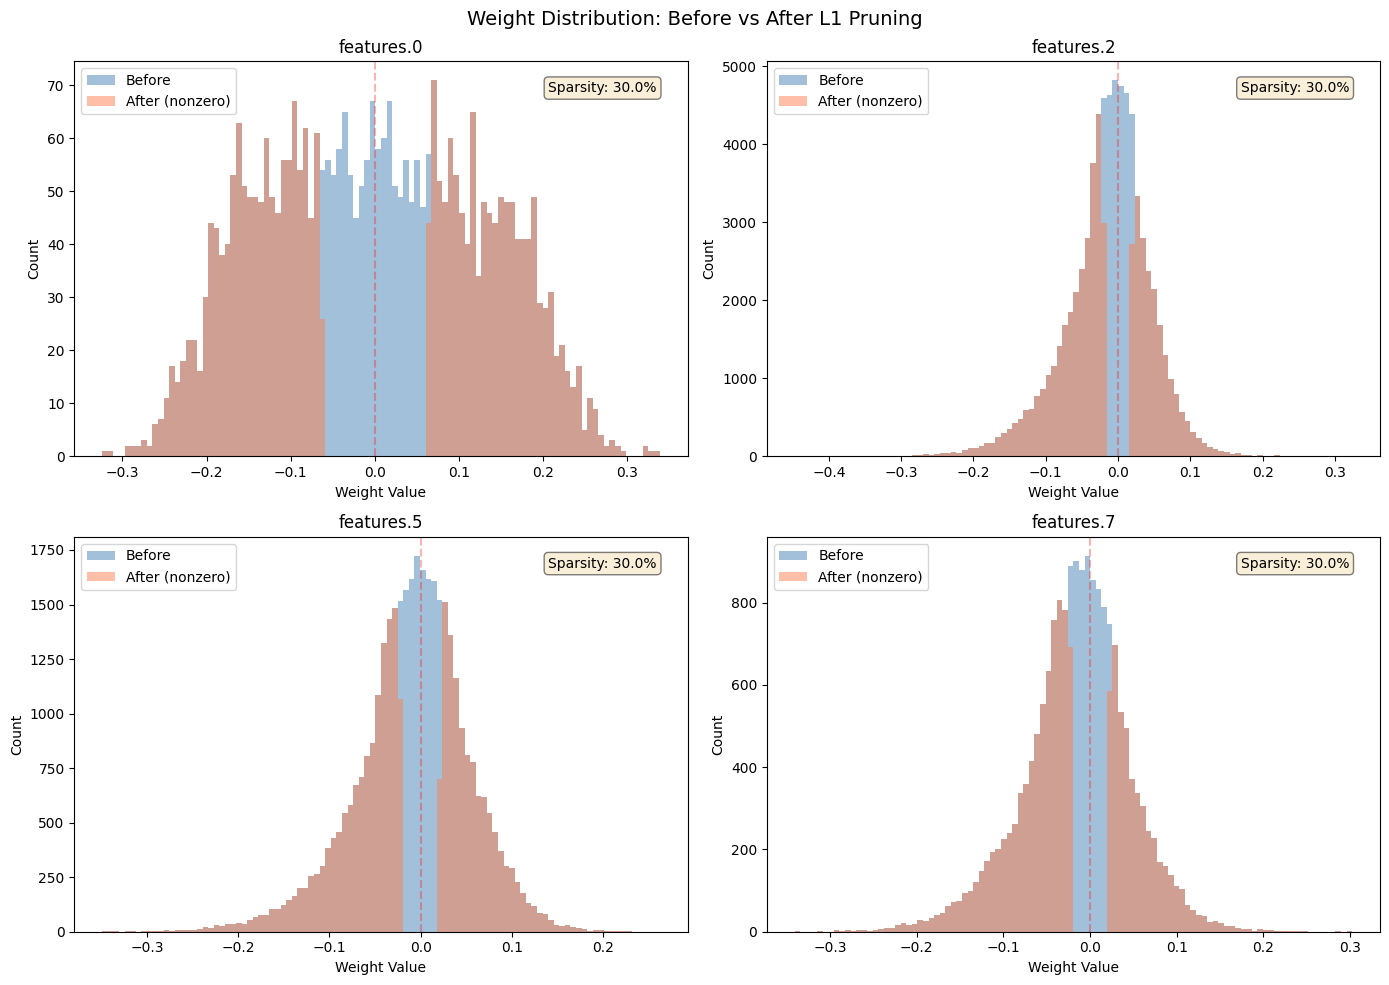

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Weight Distribution: Before vs After L1 Pruning', fontsize=14)

orig_conv = [(n, m) for n, m in original_model.named_modules() if isinstance(m, nn.Conv2d)]
pruned_conv = [(n, m) for n, m in l1_model.named_modules() if isinstance(m, nn.Conv2d)]

for idx in range(min(4, len(orig_conv))):
    ax = axes[idx // 2][idx % 2]
    name = orig_conv[idx][0]
    orig_w = orig_conv[idx][1].weight.data.cpu().numpy().flatten()
    pruned_w = pruned_conv[idx][1].weight.data.cpu().numpy().flatten()
    nonzero_pruned = pruned_w[pruned_w != 0]

    ax.hist(orig_w, bins=100, alpha=0.5, label='Before', color='steelblue')
    ax.hist(nonzero_pruned, bins=100, alpha=0.5, label='After (nonzero)', color='coral')
    ax.axvline(x=0, color='red', linestyle='--', alpha=0.3)
    ax.set_title(name)
    ax.set_xlabel('Weight Value')
    ax.set_ylabel('Count')
    ax.legend()

    sparsity = (pruned_w == 0).sum() / pruned_w.size * 100
    ax.text(0.95, 0.95, f'Sparsity: {sparsity:.1f}%',
            transform=ax.transAxes, fontsize=10,
            verticalalignment='top', horizontalalignment='right',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.show()

## 7. Random Unstructured Pruning

무작위로 가중치를 제거합니다. L1 pruning과 비교하여 **magnitude 기반 pruning의 우수성을 검증**합니다.

In [10]:
print(f"[4] Random Unstructured Pruning ({PRUNING_AMOUNT * 100:.0f}%)")
print("-" * 40)

random_model = copy.deepcopy(model)
for name, module in random_model.named_modules():
    if isinstance(module, (nn.Conv2d, nn.Linear)):
        prune.random_unstructured(module, name='weight', amount=PRUNING_AMOUNT)
random_model = remove_pruning_reparametrization(random_model)

random_accuracy = test(random_model, test_loader, DEVICE)
print(f"Random Pruning Accuracy: {random_accuracy:.2f}% (변화: {random_accuracy - baseline_accuracy:+.2f}%)")
print_sparsity(random_model, "Random Pruning 후 Sparsity")

[4] Random Unstructured Pruning (30%)
----------------------------------------
Random Pruning Accuracy: 57.37% (변화: -17.64%)

[Random Pruning 후 Sparsity]
전체 Sparsity: 30.0%
(0인 파라미터: 355,853 / 1,186,176)
Layer                          Sparsity   0s / Total          
------------------------------------------------------------
features.0                        30.0%      1,037 /    3,456
features.2                        30.0%     22,118 /   73,728
features.5                        30.0%     11,059 /   36,864
features.7                        30.0%      5,530 /   18,432
classifier.0                      30.0%    314,573 / 1,048,576
classifier.3                      30.0%      1,536 /    5,120


## 8. Global Unstructured Pruning

모든 레이어를 **통합**하여 전체 모델에서 가장 중요도가 낮은 가중치를 제거합니다.

**장점:**
- 레이어마다 적절한 pruning 비율이 자동 결정
- 중요한 레이어는 적게, 덜 중요한 레이어는 많이 pruning
- 일반적으로 per-layer pruning보다 성능이 좋음

In [11]:
print(f"[5] Global Unstructured Pruning ({PRUNING_AMOUNT * 100:.0f}%)")
print("-" * 40)

global_model = copy.deepcopy(model)
parameters_to_prune = []
for name, module in global_model.named_modules():
    if isinstance(module, (nn.Conv2d, nn.Linear)):
        parameters_to_prune.append((module, 'weight'))

prune.global_unstructured(
    parameters_to_prune,
    pruning_method=prune.L1Unstructured,
    amount=PRUNING_AMOUNT
)
global_model = remove_pruning_reparametrization(global_model)

global_accuracy = test(global_model, test_loader, DEVICE)
print(f"Global Pruning Accuracy: {global_accuracy:.2f}% (변화: {global_accuracy - baseline_accuracy:+.2f}%)")
print_sparsity(global_model, "Global Pruning 후 Sparsity (레이어별 비율이 다름!)")

[5] Global Unstructured Pruning (30%)
----------------------------------------
Global Pruning Accuracy: 75.05% (변화: +0.04%)

[Global Pruning 후 Sparsity (레이어별 비율이 다름!)]
전체 Sparsity: 30.0%
(0인 파라미터: 355,853 / 1,186,176)
Layer                          Sparsity   0s / Total          
------------------------------------------------------------
features.0                         6.6%        228 /    3,456
features.2                        20.9%     15,429 /   73,728
features.5                        18.5%      6,821 /   36,864
features.7                        18.5%      3,410 /   18,432
classifier.0                      31.4%    329,045 / 1,048,576
classifier.3                      18.0%        920 /    5,120


## 9. Sparsity별 정확도 변화 (L1 Unstructured)

Pruning 비율을 10%부터 90%까지 변화시키며 정확도 변화를 관찰합니다.

In [12]:
print("[6] Sparsity별 정확도 변화 (L1 Unstructured)")
print("-" * 40)

sparsity_levels = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]
l1_sparsity_results = {}

for amount in sparsity_levels:
    test_model = copy.deepcopy(model)
    test_model = apply_l1_unstructured_pruning(test_model, amount=amount)
    test_model = remove_pruning_reparametrization(test_model)
    acc = test(test_model, test_loader, DEVICE)
    l1_sparsity_results[amount * 100] = acc
    print(f"    Sparsity {amount * 100:5.1f}%: Accuracy {acc:.2f}%")

[6] Sparsity별 정확도 변화 (L1 Unstructured)
----------------------------------------
    Sparsity  10.0%: Accuracy 75.01%
    Sparsity  20.0%: Accuracy 74.97%
    Sparsity  30.0%: Accuracy 74.63%
    Sparsity  40.0%: Accuracy 73.24%
    Sparsity  50.0%: Accuracy 70.70%
    Sparsity  60.0%: Accuracy 68.03%
    Sparsity  70.0%: Accuracy 57.90%
    Sparsity  80.0%: Accuracy 35.04%
    Sparsity  90.0%: Accuracy 12.72%


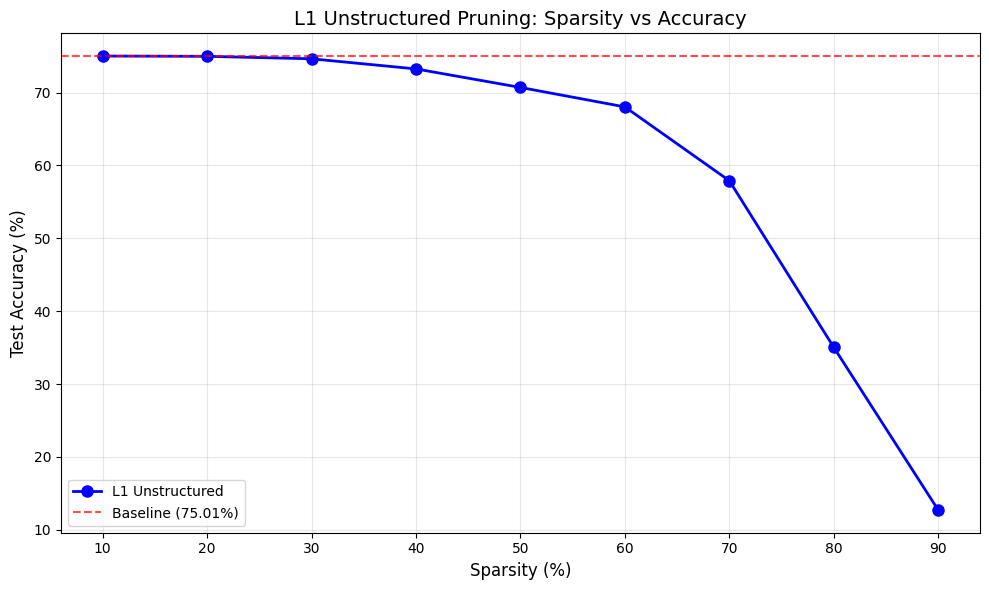

In [13]:
# Sparsity vs Accuracy 시각화
plt.figure(figsize=(10, 6))
sparsities = list(l1_sparsity_results.keys())
accuracies = list(l1_sparsity_results.values())

plt.plot(sparsities, accuracies, 'bo-', linewidth=2, markersize=8, label='L1 Unstructured')
plt.axhline(y=baseline_accuracy, color='r', linestyle='--', alpha=0.7, label=f'Baseline ({baseline_accuracy:.2f}%)')

plt.xlabel('Sparsity (%)', fontsize=12)
plt.ylabel('Test Accuracy (%)', fontsize=12)
plt.title('L1 Unstructured Pruning: Sparsity vs Accuracy', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 10. 결과 요약

In [14]:
print("=" * 60)
print("결과 요약: Unstructured Pruning (30% pruning)")
print("=" * 60)
print(f"{'방법':<35} {'정확도':<10} {'vs Baseline':<12}")
print("-" * 60)
print(f"{'Baseline (no pruning)':<35} {baseline_accuracy:>8.2f}%")
print(f"{'L1 Unstructured':<35} {l1_accuracy:>8.2f}% {l1_accuracy - baseline_accuracy:>+10.2f}%")
print(f"{'Random Unstructured':<35} {random_accuracy:>8.2f}% {random_accuracy - baseline_accuracy:>+10.2f}%")
print(f"{'Global Unstructured (L1)':<35} {global_accuracy:>8.2f}% {global_accuracy - baseline_accuracy:>+10.2f}%")
print("-" * 60)

print("\n분석:")
if l1_accuracy > random_accuracy:
    print("- L1 > Random: Magnitude 기반 pruning이 랜덤보다 효과적")
else:
    print("- Random >= L1: 이 pruning 비율에서는 차이가 크지 않음")

if global_accuracy > l1_accuracy:
    print("- Global > Per-layer: 전역적으로 중요도를 판단하는 것이 더 효과적")
else:
    print("- Per-layer >= Global: 레이어별 pruning도 충분히 효과적")

결과 요약: Unstructured Pruning (30% pruning)
방법                                  정확도        vs Baseline 
------------------------------------------------------------
Baseline (no pruning)                  75.01%
L1 Unstructured                        74.63%      -0.38%
Random Unstructured                    57.37%     -17.64%
Global Unstructured (L1)               75.05%      +0.04%
------------------------------------------------------------

분석:
- L1 > Random: Magnitude 기반 pruning이 랜덤보다 효과적
- Global > Per-layer: 전역적으로 중요도를 판단하는 것이 더 효과적


In [15]:
print("\n다음 노트북(03_structured_pruning.ipynb)에서 정형 프루닝과 Fine-tuning을 적용해봅니다.")


다음 노트북(03_structured_pruning.ipynb)에서 정형 프루닝과 Fine-tuning을 적용해봅니다.


---

## 다음 단계

**03_structured_pruning.ipynb**에서는:
1. L1/L2 Structured Pruning (필터 단위)
2. Fine-tuning (pruning 후 재학습)
3. Unstructured vs Structured 비교